# **3.3a**

## **Setup**

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import numpy as np
import pandas as pd
from pathlib import Path


# Paths

BASE_DIR = Path("/content/drive/MyDrive/FYP")
ENG_DIR = BASE_DIR / "data" / "engineered"
GDELT_DIR = BASE_DIR / "data" / "GDELT"
NLP_DIR = BASE_DIR / "data" / "nlp"
PANEL_DIR = BASE_DIR / "data" / "panel"
MODEL_DIR = BASE_DIR / "data" / "modeling"

IMS_DEST_PATH = ENG_DIR / "ims_destination_features.csv"
GDELT_VOL_PATH = GDELT_DIR / "gdelt_country_window_wide_hybridwindows_volatility.csv"
CONFLICT_COLS_PATH = PANEL_DIR / "conflict_cols.csv"
COOP_COLS_PATH = PANEL_DIR / "coop_cols.csv"

NLP_DEST_MONTHLY_PATH = NLP_DIR / "nlp_dest_drivers_monthly.csv"
NLP_ORIG_MONTHLY_PATH = NLP_DIR / "nlp_origin_drivers_monthly.csv"

# Baseline ethnic forecast (must include 2025 baseline shares)
# Expected cols: iso3, year, ethnic_group, share, total_pop_interp (or total_pop)
BASE_FORECASTS_PATH = MODEL_DIR / "ethnic_forecasts_future_models.csv"

OUT_SCENARIO = MODEL_DIR / "scenario_deltas_2025.csv"
OUT_DELTA_MIG = MODEL_DIR / "delta_mig_2025.csv"

TARGET_YEAR = 2025

### IMS: build historical migration shocks ΔM_t

In [40]:
ims = pd.read_csv(IMS_DEST_PATH)
ims["iso3"] = ims["iso3"].astype(str).str.strip().str.upper()
ims["year"] = ims["year"].astype(int)

need_cols = {"iso3","year","dest_total_migrant_stock"}
missing = list(need_cols - set(ims.columns))
if missing:
    raise ValueError(f"ims_destination_features.csv missing columns: {missing}")

ims["dest_total_migrant_stock"] = pd.to_numeric(ims["dest_total_migrant_stock"], errors="coerce")

ims = ims.dropna(subset=["dest_total_migrant_stock"]).sort_values(["iso3","year"])

# ΔM_t = migrant_stock_t - migrant_stock_(t-1) (works even if 5-year steps)
ims["delta_migrants"] = ims.groupby("iso3")["dest_total_migrant_stock"].diff()

# keep only years where delta exists
ims_d = ims.dropna(subset=["delta_migrants"]).copy()

print("IMS ΔM sample:")
display(ims_d.head())

IMS ΔM sample:


,iso3,year,dest_total_migrant_stock,n_origins,origin_hhi,delta_migrants
1,IDN,2005,90418.0,27,0.183197,-182403.0
2,IDN,2010,96493.0,27,0.182467,6075.0
3,IDN,2015,133132.0,27,0.194085,36639.0
4,IDN,2020,290640.0,27,0.222346,157508.0
5,IDN,2024,420676.0,27,0.241853,130036.0


## **GDELT: build historical geopolitics signal S_t**

In [41]:
# use the *wide* country-year GDELT file columns directly.
# S_gdelt = coop_idx - conflict_idx
# ----------------------------
gd = pd.read_csv(GDELT_VOL_PATH)
gd["iso3"] = gd["iso3"].astype(str).str.strip().str.upper()
gd["year"] = gd["year"].astype(int)

# Prefer the clean aggregated columns if present (best)
preferred_conf = ["conflict_events", "conflict_goldstein", "conflict_tone"]
preferred_coop = ["coop_events", "coop_goldstein", "coop_tone"]

conflict_cols = [c for c in preferred_conf if c in gd.columns]
coop_cols = [c for c in preferred_coop if c in gd.columns]

# Fallback: use category columns if the aggregated ones are missing
# (Your file also contains gdelt_events_* and gdelt_goldstein_* and gdelt_tone_*)
if len(conflict_cols) == 0:
    fallback_conf = [
        "gdelt_events_Conflict/Migration",
        "gdelt_goldstein_Conflict/Migration",
        "gdelt_tone_Conflict/Migration",
    ]
    conflict_cols = [c for c in fallback_conf if c in gd.columns]

if len(coop_cols) == 0:
    fallback_coop = [
        "gdelt_events_Aid/Cooperation",
        "gdelt_goldstein_Aid/Cooperation",
        "gdelt_tone_Aid/Cooperation",
    ]
    coop_cols = [c for c in fallback_coop if c in gd.columns]

# Safety checks
if len(conflict_cols) == 0:
    raise ValueError(
        "No usable conflict columns found in GDELT wide file. "
        "Expected one of: conflict_events/conflict_goldstein/conflict_tone or "
        "gdelt_*_Conflict/Migration."
    )
if len(coop_cols) == 0:
    print("Warning: No coop columns found. coop_idx will be 0 and S_gdelt will be negative-only.")

# Convert numeric
for c in conflict_cols + coop_cols:
    gd[c] = pd.to_numeric(gd[c], errors="coerce")

# Build indices
gd["conflict_idx"] = gd[conflict_cols].sum(axis=1, skipna=True)
gd["coop_idx"] = gd[coop_cols].sum(axis=1, skipna=True) if len(coop_cols) else 0.0
gd["S_gdelt"] = gd["coop_idx"] - gd["conflict_idx"]

gd_hist = gd[gd["year"] < TARGET_YEAR].copy()

print("Using conflict_cols:", conflict_cols)
print("Using coop_cols    :", coop_cols)
display(gd_hist[["iso3","year","conflict_idx","coop_idx","S_gdelt"]].head())

Using conflict_cols: ['conflict_events', 'conflict_goldstein', 'conflict_tone']
Using coop_cols    : ['coop_events', 'coop_goldstein', 'coop_tone']


,iso3,year,conflict_idx,coop_idx,S_gdelt
0,AFG,2000,38468.931039,55846.624042,17377.693003
1,AFG,2005,135513.069833,193947.491121,58434.421288
2,AFG,2010,621719.034828,461072.331258,-160646.703569
3,AFG,2015,801623.285295,762065.752072,-39557.533223
4,AFG,2020,779318.920290,762291.440743,-17027.479548


### Shock scale per country

In [42]:
m = ims_d.merge(gd_hist[["iso3","year","conflict_idx","S_gdelt"]], on=["iso3","year"], how="left")
m = m.dropna(subset=["conflict_idx"]).copy()

def shock_scale_for_iso3(df_iso, q=0.75):
    thr = df_iso["conflict_idx"].quantile(q)
    high = df_iso[df_iso["conflict_idx"] >= thr]
    if high.empty:
        return np.nan
    return float(np.median(np.abs(high["delta_migrants"].values)))

shock_scale = (m.groupby("iso3")
                 .apply(shock_scale_for_iso3)
                 .rename("shock_scale_migrants")
                 .reset_index())

print("Shock scale per iso3:")
display(shock_scale)

# Also compute historical distribution of S_gdelt for normalization reference (optional)
S_ref = (gd_hist.groupby("iso3")["S_gdelt"]
              .agg(S_med="median", S_std="std")
              .reset_index())
S_ref["S_std"] = S_ref["S_std"].replace(0.0, np.nan)

Shock scale per iso3:


/tmp/ipython-input-237960959.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(shock_scale_for_iso3)


,iso3,shock_scale_migrants
0,IDN,97073.5
1,MYS,284374.0
2,USA,2763010.5


In [43]:
print("IMS delta years:", sorted(ims_d["year"].unique())[:20])
print("GDELT years:", sorted(gd_hist["year"].unique())[:20])

IMS delta years: [np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2024)]
GDELT years: [np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2024)]


In [44]:
def load_nlp_monthly(path):
    df = pd.read_csv(path)
    # iso3 col
    if "dest_iso3" in df.columns:
        df["iso3"] = df["dest_iso3"].astype(str).str.strip().str.upper()
    elif "orig_iso3" in df.columns:
        df["iso3"] = df["orig_iso3"].astype(str).str.strip().str.upper()
    elif "iso3" in df.columns:
        df["iso3"] = df["iso3"].astype(str).str.strip().str.upper()
    else:
        raise ValueError(f"{path.name} must contain iso3 / dest_iso3 / orig_iso3 column.")

    # date/month col
    date_col = None
    for cand in ["month","date","ym","year_month","time"]:
        if cand in df.columns:
            date_col = cand
            break
    if date_col is None:
        raise ValueError(f"{path.name} needs a month/date column (month/date/ym/year_month/time).")

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["year"] = df[date_col].dt.year
    df = df[df["year"] == TARGET_YEAR].copy()

    meta = {"iso3","dest_iso3","orig_iso3",date_col,"year"}
    num_cols = [c for c in df.columns if c not in meta]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df, num_cols

def pick_cols(cols, keywords):
    out = []
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in keywords):
            out.append(c)
    return out

kw_conf = ["conflict","war","protest","sanction","violence","crisis","attack","terror"]
kw_coop = ["coop","cooperation","aid","agreement","trade","support","diplom","peace","talk"]

nlp_dest_m, dest_num_cols = load_nlp_monthly(NLP_DEST_MONTHLY_PATH)
nlp_orig_m, orig_num_cols = load_nlp_monthly(NLP_ORIG_MONTHLY_PATH)

dest_conf = pick_cols(dest_num_cols, kw_conf)
dest_coop = pick_cols(dest_num_cols, kw_coop)
orig_conf = pick_cols(orig_num_cols, kw_conf)
orig_coop = pick_cols(orig_num_cols, kw_coop)

print("DEST conflict cols:", dest_conf)
print("DEST coop cols    :", dest_coop)
print("ORIG conflict cols:", orig_conf)
print("ORIG coop cols    :", orig_coop)

# Monthly -> yearly sum per iso3
dest_y = (nlp_dest_m.groupby(["iso3","year"], as_index=False)[dest_conf + dest_coop]
                    .sum(min_count=1))
orig_y = (nlp_orig_m.groupby(["iso3","year"], as_index=False)[orig_conf + orig_coop]
                    .sum(min_count=1))

# Build indices (missing side becomes 0.0)
dest_y["dest_conflict_idx"] = dest_y[dest_conf].sum(axis=1, skipna=True) if len(dest_conf) else 0.0
dest_y["dest_coop_idx"]     = dest_y[dest_coop].sum(axis=1, skipna=True) if len(dest_coop) else 0.0

orig_y["orig_conflict_idx"] = orig_y[orig_conf].sum(axis=1, skipna=True) if len(orig_conf) else 0.0
orig_y["orig_coop_idx"]     = orig_y[orig_coop].sum(axis=1, skipna=True) if len(orig_coop) else 0.0

nlp_y = dest_y.merge(orig_y[["iso3","year","orig_conflict_idx","orig_coop_idx"]], on=["iso3","year"], how="outer")

for c in ["dest_conflict_idx","dest_coop_idx","orig_conflict_idx","orig_coop_idx"]:
    if c not in nlp_y.columns:
        nlp_y[c] = 0.0
    nlp_y[c] = nlp_y[c].fillna(0.0)

nlp_y["S_2025_nlp"] = (nlp_y["orig_conflict_idx"] + nlp_y["dest_coop_idx"]) - (nlp_y["orig_coop_idx"] + nlp_y["dest_conflict_idx"])

# Normalize NLP signal: direction-only + optional z-like scaling vs historical S_gdelt
nlp_y = nlp_y.merge(S_ref, on="iso3", how="left")
nlp_y["S_std"] = nlp_y["S_std"].replace(0.0, np.nan)

# Direction only
nlp_y["nlp_direction"] = np.sign(nlp_y["S_2025_nlp"]).astype(int)

# Relative intensity (bounded): tanh(z) where z compares to historical median/std
z = (nlp_y["S_2025_nlp"] - nlp_y["S_med"]) / nlp_y["S_std"]
nlp_y["nlp_intensity"] = np.tanh(z.replace([np.inf, -np.inf], np.nan)).fillna(0.0)

display(nlp_y[["iso3","year","S_2025_nlp","nlp_direction","nlp_intensity"]].head())


DEST conflict cols: ['conflict_topic_x', 'conflict_topic_y', 'conflict_topic', 'share_conflict_topic', 'share_conflict_topic_z']
DEST coop cols    : ['coop_topic', 'share_coop_topic', 'share_coop_topic_z']
ORIG conflict cols: ['conflict_topic_x', 'conflict_topic_y', 'conflict_topic', 'share_conflict_topic', 'share_conflict_topic_z']
ORIG coop cols    : ['coop_topic', 'share_coop_topic', 'share_coop_topic_z']


,iso3,year,S_2025_nlp,nlp_direction,nlp_intensity
0,AFG,2025,-91.711581,-1,-0.002769
1,ARG,2025,-1.211125,-1,-0.840698
2,AUS,2025,-91.922215,-1,-0.825907
3,BGD,2025,-52.632445,-1,-0.798969
4,BRA,2025,-21.762263,-1,-0.954213


In [45]:
display(nlp_y)

,iso3,year,conflict_topic_x,conflict_topic_y,conflict_topic,share_conflict_topic,share_conflict_topic_z,coop_topic,share_coop_topic,share_coop_topic_z,dest_conflict_idx,dest_coop_idx,orig_conflict_idx,orig_coop_idx,S_2025_nlp,S_med,S_std,nlp_direction,nlp_intensity
0,AFG,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,92.810999,184.522580,-91.711581,1.751067e+02,9.636757e+04,-1,-0.002769
1,ARG,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.913875,3.125000,-1.211125,4.037245e+04,3.299720e+04,-1,-0.840698
2,AUS,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,50.569893,142.492108,-91.922215,5.937695e+04,5.060654e+04,-1,-0.825907
3,BGD,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,16.451008,69.083452,-52.632445,1.161755e+04,1.065037e+04,-1,-0.798969
4,BRA,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,16.992436,38.754699,-21.762263,1.015439e+05,5.411430e+04,-1,-0.954213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,UKR,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,2771.250950,343.972327,2427.278623,NaN,NaN,1,0.000000
69,USA,2025,1496.0,-6.156653,0.0,0.0,0.0,1129.0,1.306943,-3.774758e-15,1489.843347,1130.306943,0.000000,0.000000,-359.536404,4.015161e+06,4.480812e+06,-1,-0.714423
70,VEN,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,61.507724,65.349517,-3.841792,4.643857e+04,2.540110e+04,-1,-0.949666
71,VNM,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,6.986778,64.396502,-57.409724,NaN,NaN,-1,0.000000


## **NLP Integration**

### Scenarios (2025 only)

In [46]:
# ================================
# Scenario definitions (LOW / HIGH) — FULL GRID (26)
# ================================
LEVELS = {
    "LOW":  {"aid": 0.3, "internal": 0.5, "external": 0.5},
    "HIGH": {"aid": 0.7, "internal": 1.5, "external": 1.5},
}

def scen(aid=None, internal=None, external=None):
    return {
        "aid": aid if aid is not None else 0.0,
        "internal": internal if internal is not None else 0.0,
        "external": external if external is not None else 0.0,
    }

SCENARIOS = {}

# -----------------------------
# Single-factor combinations (6)
# -----------------------------
SCENARIOS["Aid_LOW"]  = scen(aid=LEVELS["LOW"]["aid"])
SCENARIOS["Aid_HIGH"] = scen(aid=LEVELS["HIGH"]["aid"])

SCENARIOS["Conflict_internal_LOW"]  = scen(internal=LEVELS["LOW"]["internal"])
SCENARIOS["Conflict_internal_HIGH"] = scen(internal=LEVELS["HIGH"]["internal"])

SCENARIOS["Conflict_external_LOW"]  = scen(external=LEVELS["LOW"]["external"])
SCENARIOS["Conflict_external_HIGH"] = scen(external=LEVELS["HIGH"]["external"])

# ---------------------------
# Two-factor combinations (12)
# ---------------------------
# Aid & Internal
SCENARIOS["Aid_LOW__Conflict_internal_LOW"]   = scen(aid=LEVELS["LOW"]["aid"],  internal=LEVELS["LOW"]["internal"])
SCENARIOS["Aid_LOW__Conflict_internal_HIGH"]  = scen(aid=LEVELS["LOW"]["aid"],  internal=LEVELS["HIGH"]["internal"])
SCENARIOS["Aid_HIGH__Conflict_internal_LOW"]  = scen(aid=LEVELS["HIGH"]["aid"], internal=LEVELS["LOW"]["internal"])
SCENARIOS["Aid_HIGH__Conflict_internal_HIGH"] = scen(aid=LEVELS["HIGH"]["aid"], internal=LEVELS["HIGH"]["internal"])

# Aid & External
SCENARIOS["Aid_LOW__Conflict_external_LOW"]   = scen(aid=LEVELS["LOW"]["aid"],  external=LEVELS["LOW"]["external"])
SCENARIOS["Aid_LOW__Conflict_external_HIGH"]  = scen(aid=LEVELS["LOW"]["aid"],  external=LEVELS["HIGH"]["external"])
SCENARIOS["Aid_HIGH__Conflict_external_LOW"]  = scen(aid=LEVELS["HIGH"]["aid"], external=LEVELS["LOW"]["external"])
SCENARIOS["Aid_HIGH__Conflict_external_HIGH"] = scen(aid=LEVELS["HIGH"]["aid"], external=LEVELS["HIGH"]["external"])

# Internal & External
SCENARIOS["Conflict_internal_LOW__Conflict_external_LOW"]   = scen(internal=LEVELS["LOW"]["internal"],  external=LEVELS["LOW"]["external"])
SCENARIOS["Conflict_internal_LOW__Conflict_external_HIGH"]  = scen(internal=LEVELS["LOW"]["internal"],  external=LEVELS["HIGH"]["external"])
SCENARIOS["Conflict_internal_HIGH__Conflict_external_LOW"]  = scen(internal=LEVELS["HIGH"]["internal"], external=LEVELS["LOW"]["external"])
SCENARIOS["Conflict_internal_HIGH__Conflict_external_HIGH"] = scen(internal=LEVELS["HIGH"]["internal"], external=LEVELS["HIGH"]["external"])

# ----------------------------
# Three-factor combinations (8)
# ----------------------------
for a in ["LOW", "HIGH"]:
    for i in ["LOW", "HIGH"]:
        for e in ["LOW", "HIGH"]:
            name = f"Aid_{a}__Conflict_internal_{i}__Conflict_external_{e}"
            SCENARIOS[name] = scen(
                aid=LEVELS[a]["aid"],
                internal=LEVELS[i]["internal"],
                external=LEVELS[e]["external"],
            )

print("Scenarios:", len(SCENARIOS))

# ================================
# Parameters
# ================================
GAMMA_GATE = 0.6   # how strongly internal conflict suppresses inflow
ALPHA_AID  = 0.5   # effectiveness of aid
BETA_OUT   = 0.4   # outflow sensitivity to internal conflict
K_AID      = 0.5   # direct aid-driven inflow strength (same as your "+ 0.5 * aid" term)

# ================================
# Compute delta migrants per scenario
# ================================
nlp_y = nlp_y.merge(shock_scale, on="iso3", how="left")

# if a country has no shock_scale (insufficient history), set 0 to avoid NaNs
nlp_y["shock_scale_migrants"] = nlp_y["shock_scale_migrants"].fillna(0.0)

rows = []
for scen_name, cfg in SCENARIOS.items():
    tmp = nlp_y.copy()

    ext  = float(cfg["external"])
    intl = float(cfg["internal"])
    aid  = float(cfg["aid"])

    gate = np.clip(1 - GAMMA_GATE * intl, 0.1, 1.0)
    aid_mult = 1 + ALPHA_AID * aid

    # Inflow: external pull (gated) + direct aid-driven inflow
    tmp["delta_in"] = tmp["shock_scale_migrants"] * (
        ext * gate * aid_mult
        + K_AID * aid
    )

    # Outflow: increases with internal conflict
    tmp["delta_out"] = BETA_OUT * intl * tmp["shock_scale_migrants"]

    tmp["delta_migrants_2025"] = tmp["delta_in"] - tmp["delta_out"]
    tmp["scenario"] = scen_name

    rows.append(tmp[["iso3","year","scenario","delta_in","delta_out","delta_migrants_2025"]])

delta_mig = pd.concat(rows, ignore_index=True)
delta_mig.to_csv(OUT_DELTA_MIG, index=False)
print("Saved:", OUT_DELTA_MIG, "| shape:", delta_mig.shape)

print("Delta migrants 2025 sample:")
display(delta_mig.head())


Scenarios: 26
Saved: /content/drive/MyDrive/FYP/data/modeling/delta_mig_2025.csv | shape: (1898, 6)
Delta migrants 2025 sample:


,iso3,year,scenario,delta_in,delta_out,delta_migrants_2025
0,AFG,2025,Aid_LOW,0.0,0.0,0.0
1,ARG,2025,Aid_LOW,0.0,0.0,0.0
2,AUS,2025,Aid_LOW,0.0,0.0,0.0
3,BGD,2025,Aid_LOW,0.0,0.0,0.0
4,BRA,2025,Aid_LOW,0.0,0.0,0.0


In [47]:
delta_mig.groupby("scenario")["delta_migrants_2025"].mean().sort_values()

,delta_migrants_2025
scenario,
Conflict_internal_HIGH,-25844.860274
Conflict_internal_HIGH__Conflict_external_LOW,-23691.121918
Aid_LOW__Conflict_internal_HIGH,-19383.645205
Conflict_internal_HIGH__Conflict_external_HIGH,-19383.645205
Aid_LOW__Conflict_internal_HIGH__Conflict_external_LOW,-16906.846096
Aid_LOW__Conflict_internal_HIGH__Conflict_external_HIGH,-11953.247877
Aid_HIGH__Conflict_internal_HIGH,-10768.691781
Conflict_internal_LOW,-8614.953425
Aid_HIGH__Conflict_internal_HIGH__Conflict_external_LOW,-7861.145000


### Allocate ΔM_2025 into ethnic groups using baseline 2025 shares

In [48]:
ETHNIC_MAP_PATH = PANEL_DIR / "ethnic_mapping_fix.csv"
FLOWS_PATH      = ENG_DIR / "ims_od_inflow_outflow_engineered.csv"  # already in your project
BASE_FORECASTS_PATH = MODEL_DIR / "ethnic_forecasts_future_models.csv"

TARGET_YEAR = 2025

# ---------- Load mapping ----------
emap = pd.read_csv(ETHNIC_MAP_PATH)
emap["iso3_dest"] = emap["iso3_dest"].astype(str).str.strip().str.upper()
emap["iso3_orig"] = emap["iso3_orig"].astype(str).str.strip().str.upper()
emap["dest_ethnic_bucket"] = emap["dest_ethnic_bucket"].astype(str)

# ---------- Load OD flows (weights for where inflow originates) ----------
flows = pd.read_csv(FLOWS_PATH)
# expected columns typically include: iso3_dest, iso3_orig, year, migrant_stock (or similar)
flows["iso3_dest"] = flows["iso3_dest"].astype(str).str.strip().str.upper()
flows["iso3_orig"] = flows["iso3_orig"].astype(str).str.strip().str.upper()
flows["year"] = flows["year"].astype(int)

weight_col = "migrant_stock"
if weight_col not in flows.columns:
    raise ValueError(f"Expected '{weight_col}' in flows. Found: {flows.columns.tolist()}")

flows[weight_col] = pd.to_numeric(flows[weight_col], errors="coerce").fillna(0.0)

# Use latest pre-2025 year for OD composition (policy-friendly assumption)
flows_hist = flows[flows["year"] < TARGET_YEAR].copy()
last_year = int(flows_hist["year"].max())
flows_base = flows_hist[flows_hist["year"] == last_year].copy()

# ---------- Build OD→bucket weights per dest ----------
flows_map = flows_base.merge(
    emap[["iso3_dest","iso3_orig","dest_ethnic_bucket"]],
    on=["iso3_dest","iso3_orig"],
    how="left"
)
flows_map["dest_ethnic_bucket"] = flows_map["dest_ethnic_bucket"].fillna("Other")

bucket_w = (flows_map.groupby(["iso3_dest","dest_ethnic_bucket"], as_index=False)[weight_col]
            .sum())

# normalize to weights that sum to 1 per dest
den = bucket_w.groupby("iso3_dest")[weight_col].transform("sum").replace(0.0, np.nan)
bucket_w["w_in"] = (bucket_w[weight_col] / den).fillna(0.0)

bucket_w = bucket_w.rename(columns={"iso3_dest":"iso3", "dest_ethnic_bucket":"ethnic_group"})
bucket_w = bucket_w[["iso3","ethnic_group","w_in"]].copy()

# ---------- Baseline 2025 shares for ΔOUT allocation + base_share ----------
fore = pd.read_csv(BASE_FORECASTS_PATH)
fore["iso3"] = fore["iso3"].astype(str).str.strip().str.upper()
fore["year"] = fore["year"].astype(int)
fore["ethnic_group"] = fore["ethnic_group"].astype(str)
fore["share"] = pd.to_numeric(fore["share"], errors="coerce").fillna(0.0)

# Pick a single baseline model for 2025 (use your agreed BASE model name if preferred)
if "model_name" in fore.columns:
    candidate_models = [m for m in fore["model_name"].dropna().unique().tolist() if str(m).upper() != "HIST"]
    base_model = sorted(candidate_models)[0] if candidate_models else None
else:
    base_model = None

f2025 = fore[fore["year"] == TARGET_YEAR].copy()
if base_model is not None and "model_name" in f2025.columns:
    f2025 = f2025[f2025["model_name"] == base_model].copy()

pop_col = "total_pop_interp" if "total_pop_interp" in f2025.columns else ("total_pop" if "total_pop" in f2025.columns else None)
if pop_col is None:
    raise ValueError("Baseline forecasts need total_pop_interp or total_pop for 2025.")

# normalize shares for safety
share_sum = f2025.groupby("iso3")["share"].transform("sum").replace(0.0, np.nan)
f2025["share_norm"] = (f2025["share"] / share_sum).fillna(0.0)

base_alloc = f2025[["iso3","ethnic_group","share","share_norm",pop_col]].copy().rename(columns={pop_col:"total_pop_interp"})


In [49]:
base_alloc

,iso3,ethnic_group,share,share_norm,total_pop_interp
132,IDN,"Banjar, Melayu Banjar",0.072909,0.072909,2.927745e+08
138,IDN,Banten,0.023430,0.023430,2.927745e+08
144,IDN,Betawi,0.037739,0.037739,2.927745e+08
150,IDN,"Bugis, Ugi",0.033750,0.033750,2.927745e+08
156,IDN,Jawa,0.371387,0.371387,2.927745e+08
162,IDN,Madura,0.030109,0.030109,2.927745e+08
168,IDN,Minangkabau,0.031725,0.031725,2.927745e+08
174,IDN,Other,0.247068,0.247068,2.927745e+08
180,IDN,"Sunda, Priangan",0.151883,0.151883,2.927745e+08
186,MYS,Chinese,0.202413,0.202413,3.465681e+07


In [50]:
# ---------- Cross-join scenarios onto groups ----------
scen_keys = delta_mig[["iso3","scenario"]].drop_duplicates()

# Create a master list of destination ethnic groups to allocate on:
# union of baseline groups + bucket groups
groups_union = pd.concat([
    base_alloc[["iso3","ethnic_group"]].drop_duplicates(),
    bucket_w[["iso3","ethnic_group"]].drop_duplicates()
], ignore_index=True).drop_duplicates()

alloc = groups_union.merge(scen_keys, on="iso3", how="inner")

# Attach inflow weights (OD buckets). Groups missing in bucket_w get 0 inflow weight.
alloc = alloc.merge(bucket_w, on=["iso3","ethnic_group"], how="left")
alloc["w_in"] = pd.to_numeric(alloc["w_in"], errors="coerce").fillna(0.0)

# Attach baseline shares for outflow + base_share
alloc = alloc.merge(base_alloc[["iso3","ethnic_group","share","share_norm","total_pop_interp"]],
                    on=["iso3","ethnic_group"], how="left")
alloc["share_norm"] = pd.to_numeric(alloc["share_norm"], errors="coerce").fillna(0.0)
alloc["share"] = pd.to_numeric(alloc["share"], errors="coerce").fillna(0.0)

# If total_pop missing for bucket-only groups, fill using country total_pop from baseline
pop_ref = base_alloc[["iso3","total_pop_interp"]].drop_duplicates()
alloc = alloc.merge(pop_ref, on="iso3", how="left", suffixes=("","_ref"))
alloc["total_pop_interp"] = alloc["total_pop_interp"].fillna(alloc["total_pop_interp_ref"])
alloc = alloc.drop(columns=["total_pop_interp_ref"])

# Attach scenario-level delta_in / delta_out / net
alloc = alloc.merge(
    delta_mig[["iso3","scenario","delta_in","delta_out","delta_migrants_2025"]],
    on=["iso3","scenario"], how="left"
)
alloc["year"] = TARGET_YEAR

In [51]:
# ---------- Allocate ----------
# ΔIN goes into OD bucket weights (w_in)
alloc["delta_in_group"] = alloc["w_in"] * alloc["delta_in"]

# ΔOUT removed from baseline composition (share_norm)
alloc["delta_out_group"] = alloc["share_norm"] * alloc["delta_out"]

# Net delta_count per group
alloc["delta_count"] = alloc["delta_in_group"] - alloc["delta_out_group"]

# Convert to delta_share relative to total population
alloc["delta_share"] = np.where(
    alloc["total_pop_interp"].astype(float) > 0,
    alloc["delta_count"] / alloc["total_pop_interp"].astype(float),
    0.0
)

alloc["base_share"] = alloc["share"]
alloc["shock_share"] = alloc["base_share"] + alloc["delta_share"]

scenario_deltas_2025 = alloc[[
    "iso3","ethnic_group","year","scenario",
    "base_share","shock_share","delta_share",
    "total_pop_interp","delta_count",
    "delta_migrants_2025","delta_in","delta_out"
]].copy()

# Filter for specified ISO3 codes
scenario_deltas_2025 = scenario_deltas_2025[scenario_deltas_2025["iso3"].isin(["IDN", "USA", "MYS"])].copy()

scenario_deltas_2025.to_csv(OUT_SCENARIO, index=False)
print("Saved:", OUT_SCENARIO, "| shape:", scenario_deltas_2025.shape, "| baseline model:", base_model)


Saved: /content/drive/MyDrive/FYP/data/modeling/scenario_deltas_2025.csv | shape: (624, 12) | baseline model: ET_BASE


In [52]:
scenario_deltas_2025

,iso3,ethnic_group,year,scenario,base_share,shock_share,delta_share,total_pop_interp,delta_count,delta_migrants_2025,delta_in,delta_out
0,IDN,"Banjar, Melayu Banjar",2025,Aid_LOW,0.072909,0.072909,2.466822e-08,2.927745e+08,7.222225,1.456102e+04,1.456102e+04,0.0
1,IDN,"Banjar, Melayu Banjar",2025,Aid_HIGH,0.072909,0.072909,5.755917e-08,2.927745e+08,16.851858,3.397572e+04,3.397572e+04,0.0
2,IDN,"Banjar, Melayu Banjar",2025,Conflict_internal_LOW,0.072909,0.072904,-4.834779e-06,2.927745e+08,-1415.500009,-1.941470e+04,0.000000e+00,19414.7
3,IDN,"Banjar, Melayu Banjar",2025,Conflict_internal_HIGH,0.072909,0.072894,-1.450434e-05,2.927745e+08,-4246.500027,-5.824410e+04,0.000000e+00,58244.1
4,IDN,"Banjar, Melayu Banjar",2025,Conflict_external_LOW,0.072909,0.072909,8.222739e-08,2.927745e+08,24.074082,4.853675e+04,4.853675e+04,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1997,USA,Other,2025,Aid_LOW__Conflict_internal_HIGH__Conflict_exte...,0.000000,0.000011,1.095461e-05,3.447759e+08,3776.885970,-7.667354e+05,8.910709e+05,1657806.3
1998,USA,Other,2025,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,0.000000,0.000028,2.793851e-05,3.447759e+08,9632.523132,1.719974e+06,2.272576e+06,552602.1
1999,USA,Other,2025,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,0.000000,0.000060,6.003807e-05,3.447759e+08,20699.677368,4.331019e+06,4.883621e+06,552602.1
2000,USA,Other,2025,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,0.000000,0.000014,1.418155e-05,3.447759e+08,4889.457030,-5.042494e+05,1.153557e+06,1657806.3


## **Sanity checks**

In [53]:
# ---------- Sanity checks ----------
chk = (scenario_deltas_2025.groupby(["iso3","scenario"], as_index=False)
       .agg(sum_delta_count=("delta_count","sum"),
            delta_net=("delta_migrants_2025","first"),
            delta_in=("delta_in","first"),
            delta_out=("delta_out","first")))
chk["abs_err_net_alloc"] = (chk["sum_delta_count"] - chk["delta_net"]).abs()
chk["abs_err_parts"] = ((chk["delta_in"] - chk["delta_out"]) - chk["delta_net"]).abs()

display(chk.sort_values(["iso3","scenario"]).head(30))
print("Max abs_err_net_alloc:", chk["abs_err_net_alloc"].max())
print("Max abs_err_parts:", chk["abs_err_parts"].max())

,iso3,scenario,sum_delta_count,delta_net,delta_in,delta_out,abs_err_net_alloc,abs_err_parts
0,IDN,Aid_HIGH,33975.72500,33975.72500,33975.72500,0.0,0.000000e+00,0.0
1,IDN,Aid_HIGH__Conflict_external_HIGH,230549.56250,230549.56250,230549.56250,0.0,2.910383e-11,0.0
2,IDN,Aid_HIGH__Conflict_external_LOW,99500.33750,99500.33750,99500.33750,0.0,1.455192e-11,0.0
3,IDN,Aid_HIGH__Conflict_internal_HIGH,-24268.37500,-24268.37500,33975.72500,58244.1,0.000000e+00,0.0
4,IDN,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,-4610.99125,-4610.99125,53633.10875,58244.1,0.000000e+00,0.0
5,IDN,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,-17715.91375,-17715.91375,40528.18625,58244.1,0.000000e+00,0.0
6,IDN,Aid_HIGH__Conflict_internal_LOW,14561.02500,14561.02500,33975.72500,19414.7,1.818989e-12,0.0
7,IDN,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,152162.71125,152162.71125,171577.41125,19414.7,0.000000e+00,0.0
8,IDN,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,60428.25375,60428.25375,79842.95375,19414.7,0.000000e+00,0.0
9,IDN,Aid_LOW,14561.02500,14561.02500,14561.02500,0.0,0.000000e+00,0.0


Max abs_err_net_alloc: 9.313225746154785e-10
Max abs_err_parts: 0.0


## **Visualization**

Using BASE_MODEL: ET_BASE
Available scenarios: ['Aid_HIGH', 'Aid_HIGH__Conflict_external_HIGH', 'Aid_HIGH__Conflict_external_LOW', 'Aid_HIGH__Conflict_internal_HIGH', 'Aid_HIGH__Conflict_internal_HIGH__Conflict_external_HIGH', 'Aid_HIGH__Conflict_internal_HIGH__Conflict_external_LOW', 'Aid_HIGH__Conflict_internal_LOW', 'Aid_HIGH__Conflict_internal_LOW__Conflict_external_HIGH', 'Aid_HIGH__Conflict_internal_LOW__Conflict_external_LOW', 'Aid_LOW', 'Aid_LOW__Conflict_external_HIGH', 'Aid_LOW__Conflict_external_LOW', 'Aid_LOW__Conflict_internal_HIGH', 'Aid_LOW__Conflict_internal_HIGH__Conflict_external_HIGH', 'Aid_LOW__Conflict_internal_HIGH__Conflict_external_LOW', 'Aid_LOW__Conflict_internal_LOW', 'Aid_LOW__Conflict_internal_LOW__Conflict_external_HIGH', 'Aid_LOW__Conflict_internal_LOW__Conflict_external_LOW', 'Conflict_external_HIGH', 'Conflict_external_LOW', 'Conflict_internal_HIGH', 'Conflict_internal_HIGH__Conflict_external_HIGH', 'Conflict_internal_HIGH__Conflict_external_LOW', 'Conf

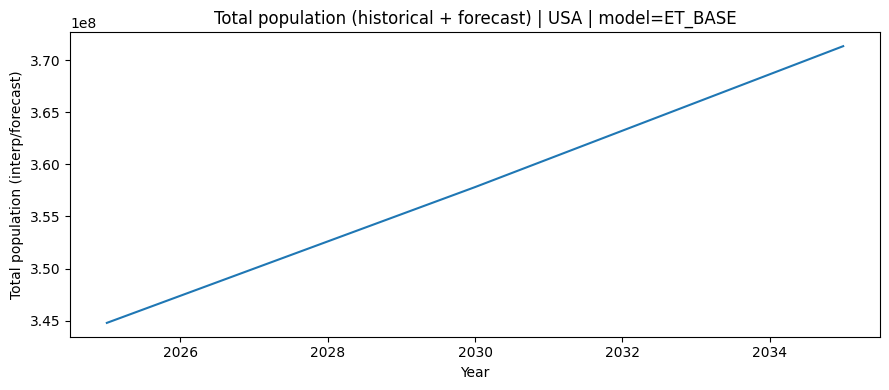

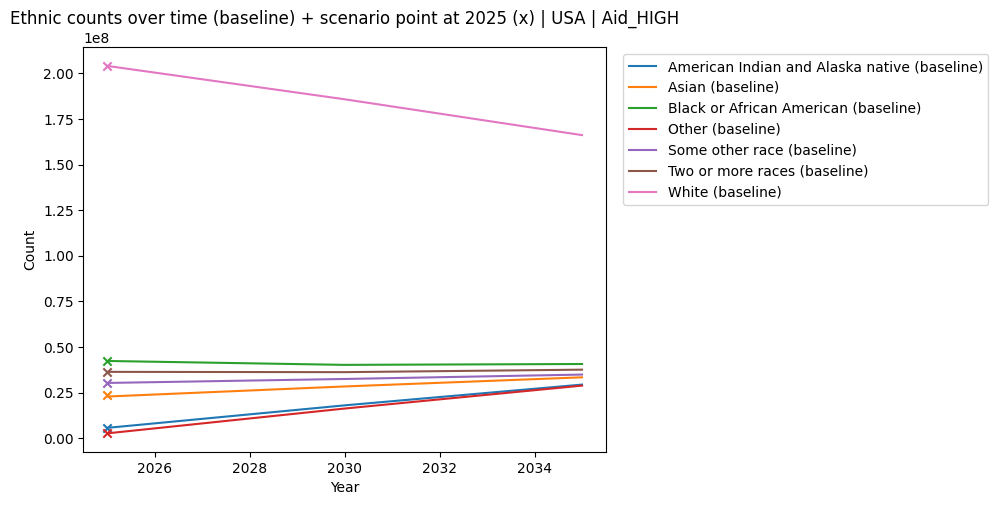

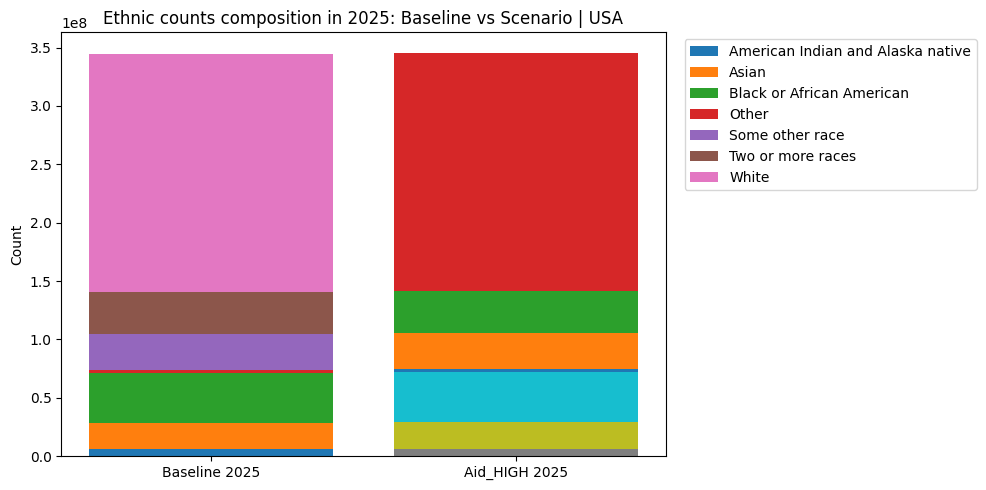

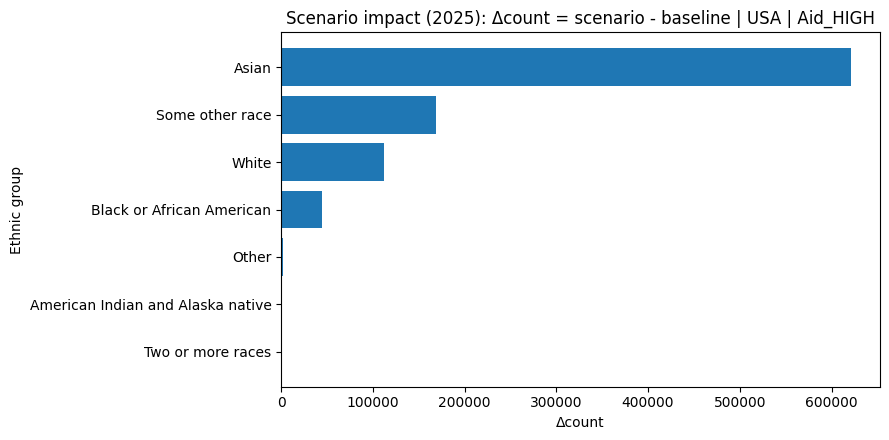

,ethnic_group_stack,delta_count
5,Two or more races,1178.206961
0,American Indian and Alaska native,1363.935164
3,Other,2045.902746
2,Black or African American,44575.928198
6,White,112631.181919
4,Some other race,169159.712707
1,Asian,621770.347563


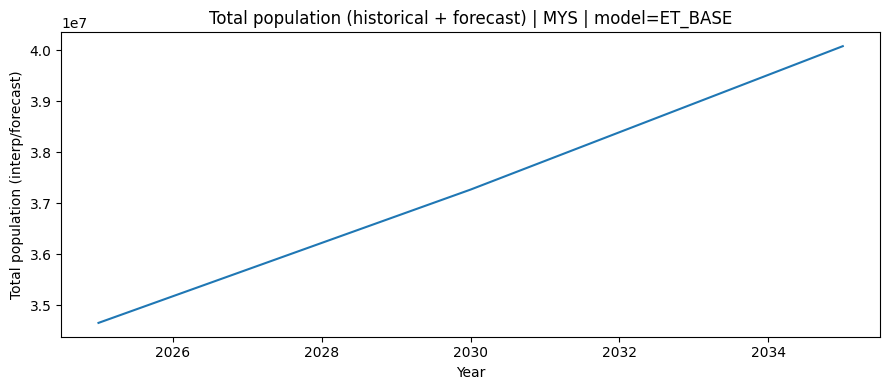

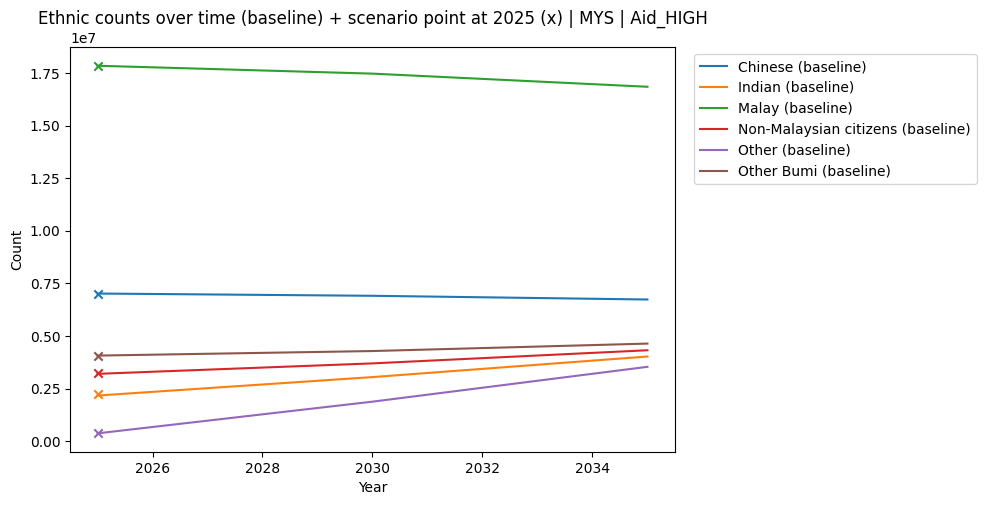

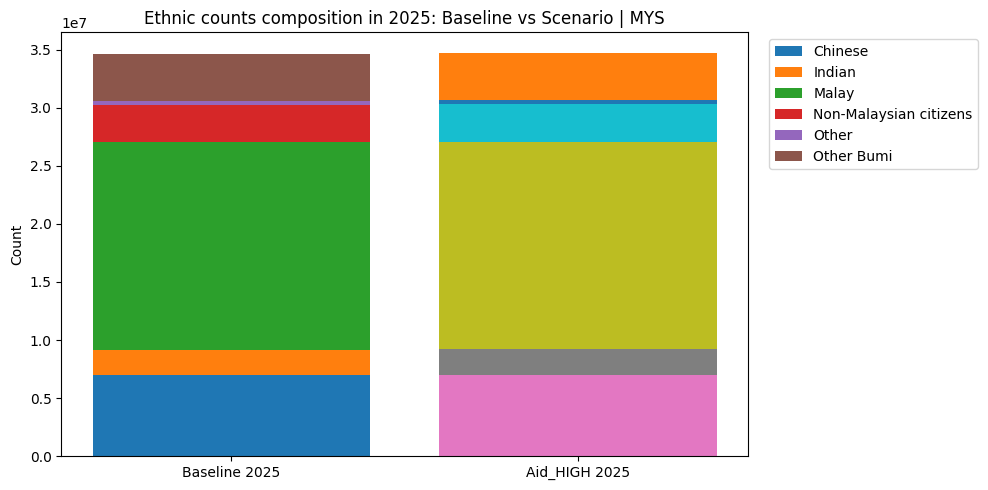

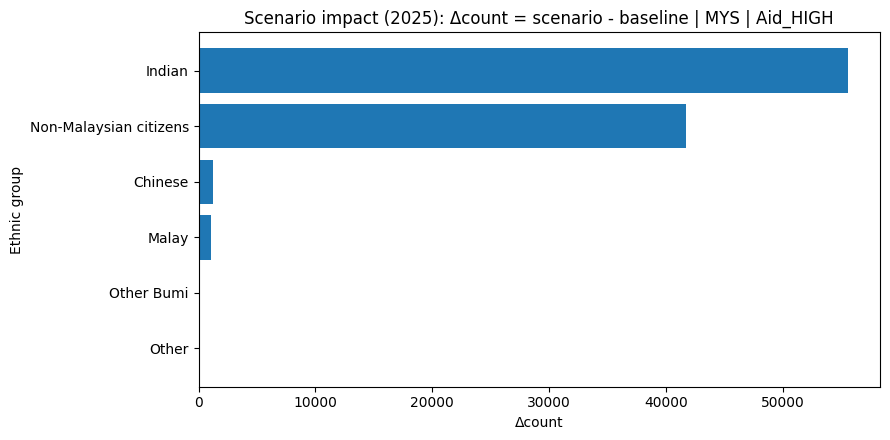

,ethnic_group_stack,delta_count
4,Other,0.000000
5,Other Bumi,3.064256
2,Malay,1067.910711
0,Chinese,1262.213537
3,Non-Malaysian citizens,41681.798819
1,Indian,55515.912677


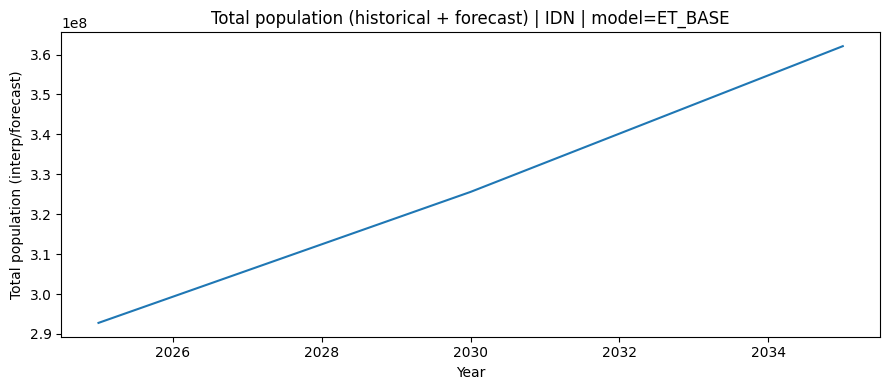

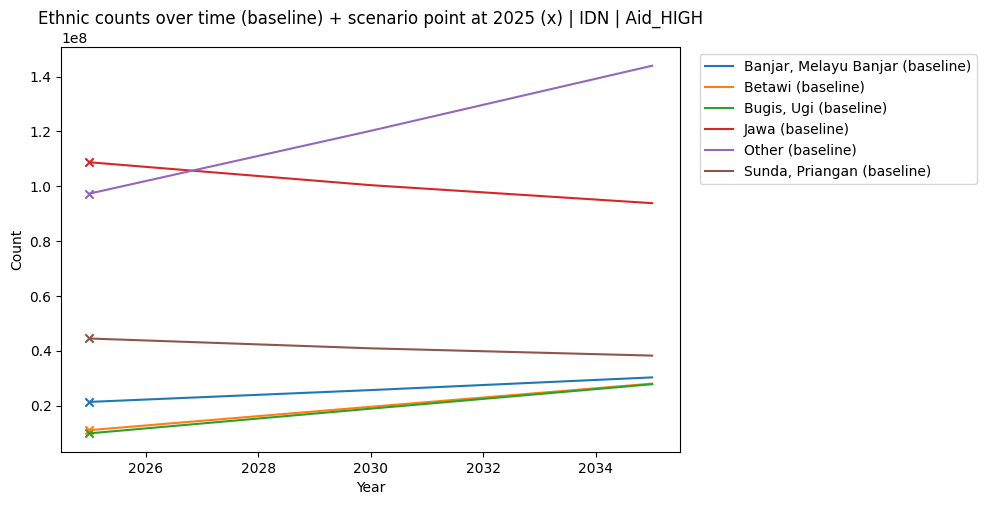

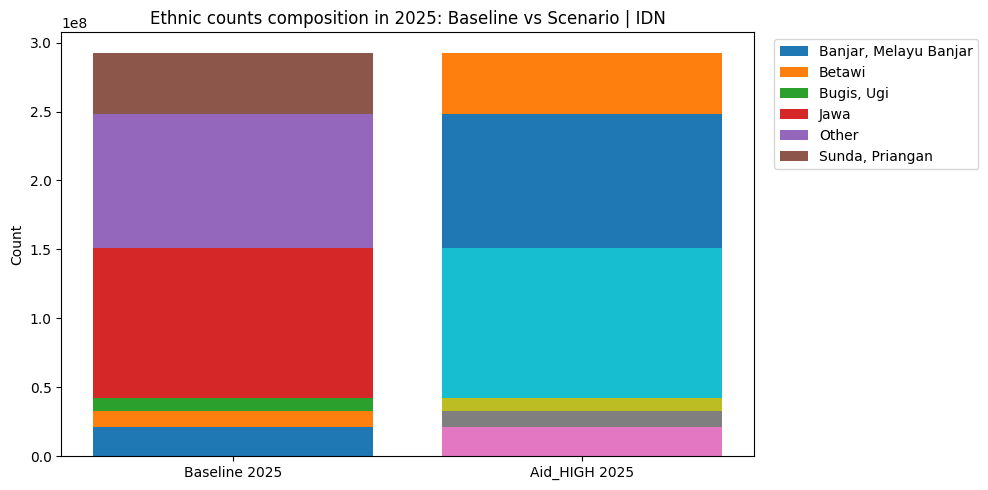

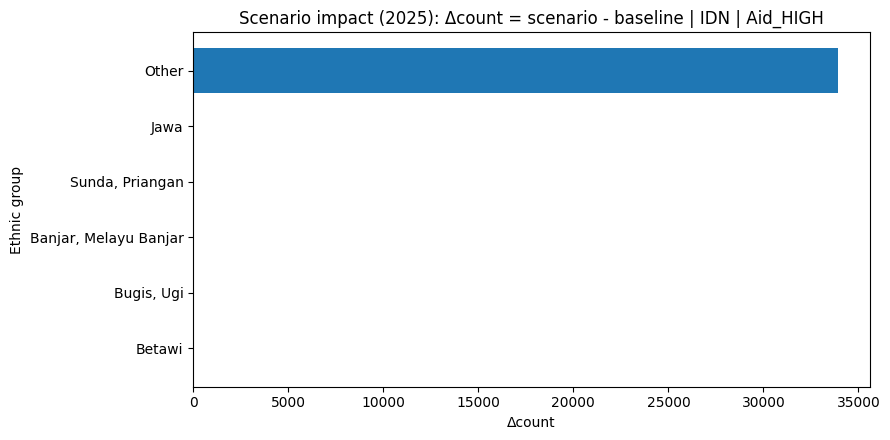

,ethnic_group_stack,delta_count
1,Betawi,0.000000
2,"Bugis, Ugi",0.000000
0,"Banjar, Melayu Banjar",16.851858
5,"Sunda, Priangan",16.851858
3,Jawa,23.831480
4,Other,33918.189805


In [54]:
# ============================================================
# Notebook check: Combine (HIST + baseline forecast) with scenario deltas (2025 only)
# Visuals per country: (1) Total pop, (2) Ethnic counts time series + scenario 2025,
# (3) 2025 baseline vs scenario composition (stacked bars), (4) Δcount by group
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/FYP")
MODEL_DIR = BASE_DIR / "data" / "modeling"

FORECASTS_PATH = MODEL_DIR / "ethnic_forecasts_future_models.csv"
SCEN_PATH      = MODEL_DIR / "scenario_deltas_2025.csv"
SCORES_PATH    = MODEL_DIR / "model_scores_overall.csv"   # optional

# ---------------- Load ----------------
fore = pd.read_csv(FORECASTS_PATH)
scen = pd.read_csv(SCEN_PATH)

# Standardize dtypes/columns
for df in (fore, scen):
    df["iso3"] = df["iso3"].astype(str).str.strip().str.upper()
    df["year"] = df["year"].astype(int)
    df["ethnic_group"] = df["ethnic_group"].astype(str)

# Try to standardize total pop column name in forecasts
# (your pipeline uses total_pop_interp; keep that)
if "total_pop_interp" not in fore.columns:
    # fallback if your file uses total_pop
    if "total_pop" in fore.columns:
        fore["total_pop_interp"] = fore["total_pop"]
    else:
        raise ValueError("Forecast file must include total_pop_interp (or total_pop).")

# Ensure count exists
if "count" not in fore.columns:
    raise ValueError("Forecast file must include 'count'.")

# Ensure share exists
if "share" not in fore.columns:
    raise ValueError("Forecast file must include 'share'.")

# If 'type' missing, create a best-effort one
if "type" not in fore.columns:
    # assume year<=2024 as HIST, future as forecast
    fore["type"] = np.where(fore["year"] <= 2024, "historical", "forecast")

# ---------------- Choose baseline model ----------------
def pick_baseline_model(fore, scores_path=None, prefer_feature_set="BASE"):
    # prefer best model from scores_overall if exists
    if scores_path and Path(scores_path).exists():
        s = pd.read_csv(scores_path)
        # pick best MAE, ignoring baseline persistence if present
        if "MAE" in s.columns and "model_name" in s.columns:
            s2 = s.copy()
            if "model_name" in s2.columns:
                s2 = s2[s2["model_name"].ne("ET_BASE")]
            if "feature_set" in s2.columns and (s2["feature_set"] == prefer_feature_set).any():
                return s2[s2["feature_set"] == prefer_feature_set].sort_values("MAE").iloc[0]["model_name"]
            return s2.sort_values("MAE").iloc[0]["model_name"]

    # fallback: choose first non-HIST model in forecasts
    models = [m for m in fore["model_name"].dropna().unique().tolist() if str(m).upper() != "HIST"]
    if len(models) == 0:
        raise ValueError("No forecast model_name found (non-HIST).")
    return models[0]

# Explicitly use the model that generated scenario_deltas_2025.csv
# This value is based on the output from cell ViFsXplgjDBB
BASE_MODEL = "ET_BASE"
print("Using BASE_MODEL:", BASE_MODEL)

# ---------------- Choose scenario ----------------
available_scenarios = sorted(scen["scenario"].dropna().unique().tolist())
print("Available scenarios:", available_scenarios)

SCENARIO = available_scenarios[0] if available_scenarios else None
print("Using SCENARIO:", SCENARIO)

# ---------------- Helper: build scenario 2025 overlay ----------------
def build_2025_overlay(fore, scen, iso3, base_model, scenario_name):
    """
    Returns:
      base_2025: baseline 2025 rows (iso3 only)
      scen_2025: scenario 2025 rows merged with baseline -> scenario_count/share
      delta_tbl: delta_count by group for 2025
    """
    iso3 = str(iso3).upper()

    base_2025 = fore[
        (fore["iso3"] == iso3) &
        (fore["year"] == 2025) &
        (fore["model_name"] == base_model)
    ].copy()

    if base_2025.empty:
        raise ValueError(f"No baseline rows for {iso3} year=2025 model={base_model}. Check forecasts file.")

    delta_tbl = scen[
        (scen["iso3"] == iso3) &
        (scen["year"] == 2025) &
        (scen["scenario"] == scenario_name)
    ][["iso3","ethnic_group","delta_count"]].copy()

    if delta_tbl.empty:
        raise ValueError(f"No scenario delta rows for {iso3}, 2025, scenario={scenario_name}.")

    merged = base_2025.merge(delta_tbl, on=["iso3","ethnic_group"], how="left")
    merged["delta_count"] = pd.to_numeric(merged["delta_count"], errors="coerce").fillna(0.0)
    merged["scenario_count"] = pd.to_numeric(merged["count"], errors="coerce") + merged["delta_count"]

    # recompute scenario shares to guarantee sum=1
    denom = merged["scenario_count"].sum()
    merged["scenario_share"] = merged["scenario_count"] / denom if denom != 0 else 0.0

    return base_2025, merged, delta_tbl

# ---------------- Main visual function ----------------
def plot_country_views(iso3, top_n=6):
    iso3 = str(iso3).upper()

    # (A) total population line (HIST + baseline years)
    pop = (fore[(fore["iso3"] == iso3) & (fore["model_name"] == BASE_MODEL)]
           [["year","total_pop_interp"]]
           .drop_duplicates()
           .sort_values("year")
           .copy())

    plt.figure(figsize=(9,4))
    plt.plot(pop["year"], pop["total_pop_interp"])
    plt.title(f"Total population (historical + forecast) | {iso3} | model={BASE_MODEL}")
    plt.xlabel("Year"); plt.ylabel("Total population (interp/forecast)")
    plt.tight_layout()
    plt.show()

    # Build baseline HIST + baseline forecast series for counts/shares
    hist = fore[(fore["iso3"] == iso3) & (fore["year"] <= 2024)].copy()
    base = fore[(fore["iso3"] == iso3) & (fore["model_name"] == BASE_MODEL)].copy()

    # Keep only relevant years for display
    base = base[base["year"].isin(sorted(set(hist["year"].unique().tolist() + [2025, 2030, 2035])))].copy()

    # Choose top groups by baseline 2025 count
    base_2025, scen_2025, delta_tbl = build_2025_overlay(fore, scen, iso3, BASE_MODEL, SCENARIO)
    base_2025 = base_2025.copy()
    base_2025["count"] = pd.to_numeric(base_2025["count"], errors="coerce")
    top_groups = (base_2025.sort_values("count", ascending=False)["ethnic_group"].head(top_n).tolist())

    def group_other(df, value_col, label_col="ethnic_group"):
        df = df.copy()
        df["ethnic_group_stack"] = np.where(df[label_col].isin(top_groups), df[label_col], "Other")
        out = (df.groupby(["year","ethnic_group_stack"], as_index=False)[value_col].sum())
        return out

    # (B) Ethnic counts over time (baseline), with scenario overlay at 2025
    base_counts = group_other(base, "count")
    base_counts_piv = base_counts.pivot(index="year", columns="ethnic_group_stack", values="count").fillna(0.0)

    # Scenario 2025 counts, grouped
    scen_counts = scen_2025.copy()
    scen_counts["count"] = scen_counts["scenario_count"]
    scen_counts = group_other(scen_counts, "count").rename(columns={"count":"scenario_count"})
    scen_counts_piv = scen_counts.pivot(index="year", columns="ethnic_group_stack", values="scenario_count").fillna(0.0)

    plt.figure(figsize=(10,5))
    for g in base_counts_piv.columns:
        plt.plot(base_counts_piv.index, base_counts_piv[g], label=f"{g} (baseline)")
        # overlay scenario point for 2025 only if available
        if 2025 in scen_counts_piv.index and g in scen_counts_piv.columns:
            plt.scatter([2025], [scen_counts_piv.loc[2025, g]], marker="x")
    plt.title(f"Ethnic counts over time (baseline) + scenario point at 2025 (x) | {iso3} | {SCENARIO}")
    plt.xlabel("Year"); plt.ylabel("Count")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # (C) 2025 composition: baseline vs scenario (stacked bars)
    base_bar = base_2025.copy()
    base_bar["ethnic_group_stack"] = np.where(base_bar["ethnic_group"].isin(top_groups), base_bar["ethnic_group"], "Other")
    base_bar = base_bar.groupby("ethnic_group_stack", as_index=False)["count"].sum()

    scen_bar = scen_2025.copy()
    scen_bar["ethnic_group_stack"] = np.where(scen_bar["ethnic_group"].isin(top_groups), scen_bar["ethnic_group"], "Other")
    scen_bar = scen_bar.groupby("ethnic_group_stack", as_index=False)["scenario_count"].sum()

    # ensure same group order
    groups_order = sorted(set(base_bar["ethnic_group_stack"]).union(set(scen_bar["ethnic_group_stack"]))) # Removed extraneous backtick
    base_vals = [float(base_bar[base_bar["ethnic_group_stack"] == g]["count"].sum()) for g in groups_order]
    scen_vals = [float(scen_bar[scen_bar["ethnic_group_stack"] == g]["scenario_count"].sum()) for g in groups_order]

    plt.figure(figsize=(10,5))
    bottom = 0.0
    for g, v in zip(groups_order, base_vals):
        plt.bar(["Baseline 2025"], [v], bottom=[bottom], label=g)
        bottom += v

    bottom = 0.0
    for g, v in zip(groups_order, scen_vals):
        plt.bar([f"{SCENARIO} 2025"], [v], bottom=[bottom])
        bottom += v

    plt.title(f"Ethnic counts composition in 2025: Baseline vs Scenario | {iso3}")
    plt.ylabel("Count")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # (D) Δcount by ethnic group (2025)
    delta = scen_2025.copy()
    delta["ethnic_group_stack"] = np.where(delta["ethnic_group"].isin(top_groups), delta["ethnic_group"], "Other")
    delta_agg = delta.groupby("ethnic_group_stack", as_index=False)["delta_count"].sum().sort_values("delta_count")

    plt.figure(figsize=(9,4.5))
    plt.barh(delta_agg["ethnic_group_stack"], delta_agg["delta_count"])
    plt.title(f"Scenario impact (2025): Δcount = scenario - baseline | {iso3} | {SCENARIO}")
    plt.xlabel("Δcount"); plt.ylabel("Ethnic group")
    plt.tight_layout()
    plt.show()

    display(delta_agg)

# ---------------- Run for each country (like dashboard) ----------------
for c in ["USA", "MYS", "IDN"]:
    plot_country_views(c, top_n=6)

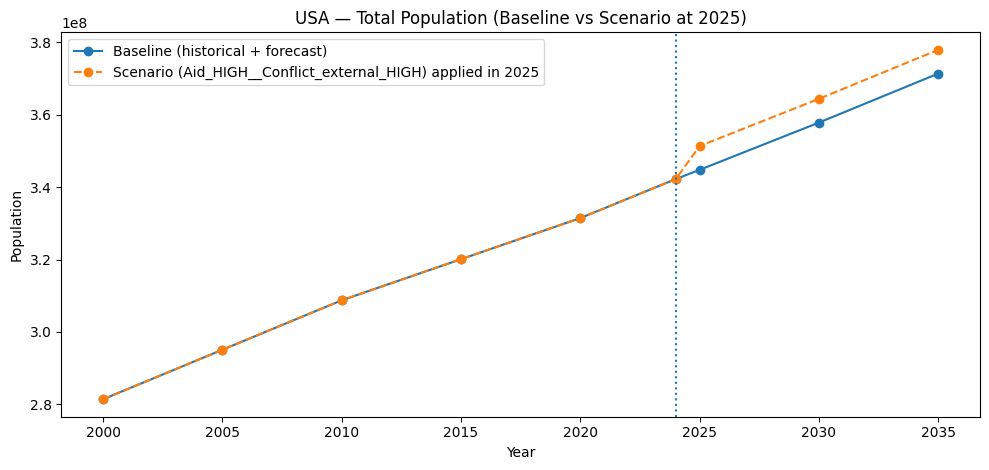

USA | Aid_HIGH__Conflict_external_HIGH | total Δcount at 2025 = 6,562,150 people


In [55]:
# ============================================================
# Add-on cell: Total population “kink” at 2025 using scenario_deltas_2025.csv
# - Uses baseline total_pop_interp from forecasts (same across models per iso3/year)
# - Computes total Δcount in 2025 from scenario_deltas_2025.csv (sum across ethnic groups)
# - Applies kink at 2025 and carries forward (visual-only, policy-friendly illustration)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Choose country + scenario ----
iso3 = "USA"
scenario_name = "Aid_HIGH__Conflict_external_HIGH"  # must exist in scen["scenario"].unique()

# ---- Baseline total_pop series (historical + forecast years) ----
# Use any model; total_pop_interp should be identical across models for same iso3/year
base_pop = (fore[(fore["iso3"] == iso3)][["year", "total_pop_interp"]]
            .drop_duplicates()
            .sort_values("year")
            .copy())

base_pop["total_pop_interp"] = pd.to_numeric(base_pop["total_pop_interp"], errors="coerce")
base_pop = base_pop.dropna(subset=["total_pop_interp"])

# ---- Scenario delta (sum across ethnic groups) for 2025 ----
scen_sub = scen[
    (scen["iso3"] == iso3) &
    (scen["year"] == 2025) &
    (scen["scenario"] == scenario_name)
].copy()

# Ensure numeric
scen_sub["delta_count"] = pd.to_numeric(scen_sub["delta_count"], errors="coerce")

if scen_sub.empty:
    raise ValueError(f"No scenario rows for {iso3} in 2025 for scenario='{scenario_name}'.")
if scen_sub["delta_count"].isna().all():
    raise ValueError(
        "delta_count is all NaN for this subset. "
        "Fix scenario_deltas_2025.csv so delta_count is computed using total_pop_interp (or merge properly)."
    )

delta_total_2025 = float(scen_sub["delta_count"].sum())

# ---- Build 'shock' population series (kink at 2025, then carry forward) ----
shock_pop = base_pop.copy()
shock_pop["pop_shock"] = shock_pop["total_pop_interp"].copy()

shock_pop.loc[shock_pop["year"] >= 2025, "pop_shock"] = (
    shock_pop.loc[shock_pop["year"] >= 2025, "pop_shock"] + delta_total_2025
)

# ---- Plot ----
plt.figure(figsize=(10, 4.8))

plt.plot(base_pop["year"], base_pop["total_pop_interp"], marker="o",
         label="Baseline (historical + forecast)")

plt.plot(shock_pop["year"], shock_pop["pop_shock"], marker="o", linestyle="--",
         label=f"Scenario ({scenario_name}) applied in 2025")

plt.axvline(2024, linestyle=":")
plt.title(f"{iso3} — Total Population (Baseline vs Scenario at 2025)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

print(f"{iso3} | {scenario_name} | total Δcount at 2025 = {delta_total_2025:,.0f} people")


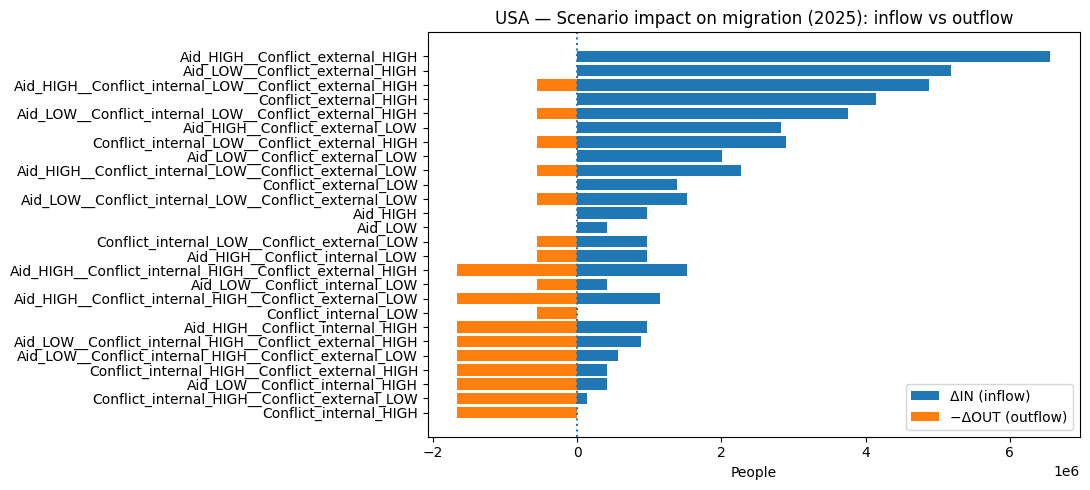

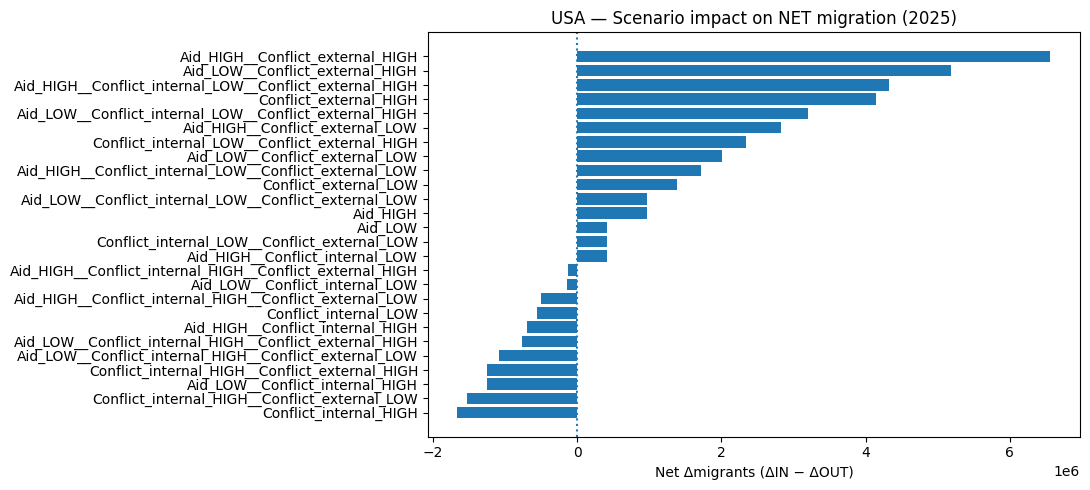

,scenario,delta_in,delta_out,delta_migrants_2025
288,Conflict_internal_HIGH,0.000000e+00,1657806.3,-1.657806e+06
1237,Conflict_internal_HIGH__Conflict_external_LOW,1.381505e+05,1657806.3,-1.519656e+06
580,Aid_LOW__Conflict_internal_HIGH,4.144516e+05,1657806.3,-1.243355e+06
1310,Conflict_internal_HIGH__Conflict_external_HIGH,4.144516e+05,1657806.3,-1.243355e+06
1529,Aid_LOW__Conflict_internal_HIGH__Conflict_exte...,5.733247e+05,1657806.3,-1.084482e+06
1602,Aid_LOW__Conflict_internal_HIGH__Conflict_exte...,8.910709e+05,1657806.3,-7.667354e+05
726,Aid_HIGH__Conflict_internal_HIGH,9.670537e+05,1657806.3,-6.907526e+05
215,Conflict_internal_LOW,0.000000e+00,552602.1,-5.526021e+05
1821,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,1.153557e+06,1657806.3,-5.042494e+05
507,Aid_LOW__Conflict_internal_LOW,4.144516e+05,552602.1,-1.381505e+05


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Pick country
iso3 = "USA"

d = delta_mig[delta_mig["iso3"] == iso3].copy()
d = d.sort_values("delta_migrants_2025")

plt.figure(figsize=(11, 5))
plt.barh(d["scenario"], d["delta_in"], label="ΔIN (inflow)")
plt.barh(d["scenario"], -d["delta_out"], label="−ΔOUT (outflow)")  # negative for visual split
plt.axvline(0, linestyle=":")
plt.title(f"{iso3} — Scenario impact on migration (2025): inflow vs outflow")
plt.xlabel("People")
plt.tight_layout()
plt.legend()
plt.show()

# Net migration chart
plt.figure(figsize=(11, 5))
plt.barh(d["scenario"], d["delta_migrants_2025"])
plt.axvline(0, linestyle=":")
plt.title(f"{iso3} — Scenario impact on NET migration (2025)")
plt.xlabel("Net Δmigrants (ΔIN − ΔOUT)")
plt.tight_layout()
plt.show()

display(d[["scenario","delta_in","delta_out","delta_migrants_2025"]])


# **3.3b**

### **Setup**

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
import numpy as np
import pandas as pd
from pathlib import Path

# =========================
# PATHS (adjust if needed)
# =========================
BASE_DIR = Path("/content/drive/MyDrive/FYP")
ENG_DIR  = BASE_DIR / "data" / "engineered"
MODEL_DIR = BASE_DIR / "data" / "modeling"

OD_HIST_PATH     = ENG_DIR / "ims_od_inflow_outflow_engineered.csv"
OD_FORE_PATH     = MODEL_DIR / "od_forecasts_future.csv"          # you said this exists
DELTA_MIG_PATH   = MODEL_DIR / "delta_mig_2025.csv"               # from 3.3 macro output
OUT_OD_SCEN_2025 = MODEL_DIR / "od_scenario_deltas_2025.csv"

TARGET_YEAR = 2025

### Load

In [59]:
od_hist = pd.read_csv(OD_HIST_PATH)
od_fore = pd.read_csv(OD_FORE_PATH)
delta_mig = pd.read_csv(DELTA_MIG_PATH)

# ---- dtypes ----
for df in [od_hist, od_fore]:
    df["iso3_orig"] = df["iso3_orig"].astype(str).str.strip().str.upper()
    df["iso3_dest"] = df["iso3_dest"].astype(str).str.strip().str.upper()
    df["year"] = df["year"].astype(int)

delta_mig["iso3"] = delta_mig["iso3"].astype(str).str.strip().str.upper()
delta_mig["year"] = delta_mig["year"].astype(int)
delta_mig["scenario"] = delta_mig["scenario"].astype(str)

# ---- numeric ----
od_hist["migrant_stock"] = pd.to_numeric(od_hist["migrant_stock"], errors="coerce").fillna(0.0)
od_fore["migrant_stock_pred"] = pd.to_numeric(od_fore["migrant_stock_pred"], errors="coerce")

delta_mig["delta_in"]  = pd.to_numeric(delta_mig["delta_in"], errors="coerce")
delta_mig["delta_out"] = pd.to_numeric(delta_mig["delta_out"], errors="coerce")
delta_mig["delta_migrants_2025"] = pd.to_numeric(delta_mig["delta_migrants_2025"], errors="coerce")

### **BUILD OD WEIGHTS from history**

use latest available pre-2025 OD composition

In [60]:
od_hist_pre = od_hist[od_hist["year"] < TARGET_YEAR].copy()
if od_hist_pre.empty:
    raise ValueError("No OD history before 2025 found in ims_od_inflow_outflow_engineered.csv")

last_year = int(od_hist_pre["year"].max())
od_base = od_hist_pre[od_hist_pre["year"] == last_year].copy()

# If shares exist, use them; otherwise compute shares safely
if "origin_share_in_dest_migrants" in od_base.columns:
    od_base["w_in"] = pd.to_numeric(od_base["origin_share_in_dest_migrants"], errors="coerce")
else:
    # compute: migrant_stock / total_in_dest
    denom = od_base.groupby("iso3_dest")["migrant_stock"].transform("sum").replace(0.0, np.nan)
    od_base["w_in"] = (od_base["migrant_stock"] / denom).fillna(0.0)

if "dest_share_of_origin_emigration" in od_base.columns:
    od_base["w_out"] = pd.to_numeric(od_base["dest_share_of_origin_emigration"], errors="coerce")
else:
    # compute: migrant_stock / total_out_origin
    denom = od_base.groupby("iso3_orig")["migrant_stock"].transform("sum").replace(0.0, np.nan)
    od_base["w_out"] = (od_base["migrant_stock"] / denom).fillna(0.0)

# Clean weights
od_base["w_in"] = od_base["w_in"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
od_base["w_out"] = od_base["w_out"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Keep only needed columns for allocation
w_in_tbl  = od_base[["iso3_orig","iso3_dest","w_in"]].copy()
w_out_tbl = od_base[["iso3_orig","iso3_dest","w_out"]].copy()

# =========================
# OD FORECAST BASE (2025 only, but you can extend later)
# =========================
od_fore_2025 = od_fore[od_fore["year"] == TARGET_YEAR].copy()
if od_fore_2025.empty:
    raise ValueError("od_forecasts_future.csv has no year=2025 rows.")

# Ensure uniqueness per OD/model (if duplicates exist, keep mean)
od_fore_2025 = (od_fore_2025
                .groupby(["iso3_orig","iso3_dest","year","model_name"], as_index=False)["migrant_stock_pred"]
                .mean())

In [61]:
od_fore_2025

,iso3_orig,iso3_dest,year,model_name,migrant_stock_pred
0,AFG,IDN,2025,XGB_OD,7.490869e+03
1,AFG,MYS,2025,XGB_OD,3.187380e+03
2,AFG,USA,2025,XGB_OD,2.126652e+05
3,ARG,USA,2025,XGB_OD,2.057898e+05
4,AUS,IDN,2025,XGB_OD,4.918993e+03
...,...,...,...,...,...
367,VNM,IDN,2025,XGB_OD,1.738108e+01
368,VNM,MYS,2025,XGB_OD,4.483977e+00
369,VNM,USA,2025,XGB_OD,1.431834e+06
370,YEM,IDN,2025,XGB_OD,6.467918e+02


### **ALLOCATE MACRO DELTAS TO OD**

Logic:
* delta_in for a DEST is distributed across origins by w_in (origin mix into that dest)
* delta_out for an ORIGIN is distributed across destinations by w_out (where that origin sends people)

Then OD shock for pair (o,d) combines:
*   migrant_stock_shock = migrant_stock_pred + delta_in_od(o->d based on dest) + delta_out_od(o->d based on origin)

NOTE:


 This is OD "flow" view. For DEST net-migration view:
   net_delta_dest = sum_in_to_dest - sum_out_from_dest

In [62]:
# Build scenario key grid
scen_keys = delta_mig[["iso3","year","scenario","delta_in","delta_out"]].drop_duplicates().copy()
scen_keys = scen_keys[scen_keys["year"] == TARGET_YEAR].copy()
if scen_keys.empty:
    raise ValueError("delta_mig_2025.csv has no year=2025 rows.")

# =========================
# WEIGHTED INFLOW ALLOCATION (DEST-normalized)
# =========================

in_alloc = w_in_tbl.merge(
    scen_keys.rename(columns={"iso3": "iso3_dest"}),
    on="iso3_dest",
    how="inner"
)

# Normalize weights per (dest, scenario)
in_alloc["w_in_norm"] = (
    in_alloc.groupby(["iso3_dest", "scenario"])["w_in"]
    .transform(lambda x: x / x.sum() if x.sum() > 0 else 0.0)
)

in_alloc["delta_in_od"] = in_alloc["w_in_norm"] * in_alloc["delta_in"]

in_alloc = in_alloc[[
    "iso3_orig", "iso3_dest", "scenario", "delta_in_od"
]]

# =========================
# WEIGHTED OUTFLOW ALLOCATION (ORIG-normalized)
# =========================

out_alloc = w_out_tbl.merge(
    scen_keys.rename(columns={"iso3": "iso3_orig"}),
    on="iso3_orig",
    how="inner"
)

# Normalize weights per (orig, scenario)
out_alloc["w_out_norm"] = (
    out_alloc.groupby(["iso3_orig", "scenario"])["w_out"]
    .transform(lambda x: x / x.sum() if x.sum() > 0 else 0.0)
)

out_alloc["delta_out_od"] = out_alloc["w_out_norm"] * out_alloc["delta_out"]

out_alloc = out_alloc[[
    "iso3_orig", "iso3_dest", "scenario", "delta_out_od"
]]

od_alloc = pd.merge(
    in_alloc,
    out_alloc,
    on=["iso3_orig", "iso3_dest", "scenario"],
    how="outer"
)

od_alloc["delta_in_od"] = od_alloc["delta_in_od"].fillna(0.0)
od_alloc["delta_out_od"] = od_alloc["delta_out_od"].fillna(0.0)

od_alloc["delta_stock_od"] = (
    od_alloc["delta_in_od"] + od_alloc["delta_out_od"]
)

od_alloc["year"] = TARGET_YEAR


od_alloc["delta_in_od"] = pd.to_numeric(od_alloc["delta_in_od"], errors="coerce").fillna(0.0)
od_alloc["delta_out_od"] = pd.to_numeric(od_alloc["delta_out_od"], errors="coerce").fillna(0.0)

# Here delta_out_od is "outflow pushed from origin" -> it INCREASES OD flow from origin to dest.
# If you want an OD-net view for a DEST, you subtract the dest's own outflows separately (see checks below).
od_alloc["delta_stock_od"] = od_alloc["delta_in_od"] + od_alloc["delta_out_od"]
od_alloc["year"] = TARGET_YEAR

# ---- Merge with OD forecast base ----
scen_out = od_fore_2025.merge(
    od_alloc,
    on=["iso3_orig","iso3_dest","year"],
    how="left"
)

scen_out["scenario"] = scen_out["scenario"].fillna("Baseline")  # if some rows have no alloc, they stay baseline
scen_out["delta_in_od"] = scen_out["delta_in_od"].fillna(0.0)
scen_out["delta_out_od"] = scen_out["delta_out_od"].fillna(0.0)
scen_out["delta_stock_od"] = scen_out["delta_stock_od"].fillna(0.0)

scen_out["migrant_stock_shock"] = scen_out["migrant_stock_pred"] + scen_out["delta_stock_od"]

# keep tidy
scen_out = scen_out[[
    "iso3_orig","iso3_dest","year","model_name",
    "scenario",
    "migrant_stock_pred",
    "delta_in_od","delta_out_od","delta_stock_od",
    "migrant_stock_shock"
]].copy()

scen_out.to_csv(OUT_OD_SCEN_2025, index=False)
print("Saved:", OUT_OD_SCEN_2025, "| shape:", scen_out.shape)
display(scen_out.head())

Saved: /content/drive/MyDrive/FYP/data/modeling/od_scenario_deltas_2025.csv | shape: (9672, 10)


,iso3_orig,iso3_dest,year,model_name,scenario,migrant_stock_pred,delta_in_od,delta_out_od,delta_stock_od,migrant_stock_shock
0,AFG,IDN,2025,XGB_OD,Aid_HIGH,7490.869456,482.891488,0.0,482.891488,7973.760944
1,AFG,IDN,2025,XGB_OD,Aid_HIGH__Conflict_external_HIGH,7490.869456,3276.763671,0.0,3276.763671,10767.633127
2,AFG,IDN,2025,XGB_OD,Aid_HIGH__Conflict_external_LOW,7490.869456,1414.182216,0.0,1414.182216,8905.051672
3,AFG,IDN,2025,XGB_OD,Aid_HIGH__Conflict_internal_HIGH,7490.869456,482.891488,0.0,482.891488,7973.760944
4,AFG,IDN,2025,XGB_OD,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,7490.869456,762.278707,0.0,762.278707,8253.148162


### SANITY CHECKS (macro vs OD allocations)

In [63]:
# =========================
# 1) For each DEST+scenario, sum(delta_in_od) ≈ delta_in(dest,scenario)
# 2) For each ORIG+scenario, sum(delta_out_od) ≈ delta_out(orig,scenario)
# =========================
chk_in = (od_alloc.groupby(["iso3_dest","scenario"], as_index=False)["delta_in_od"].sum()
          .rename(columns={"iso3_dest":"iso3","delta_in_od":"sum_delta_in_od"}))

chk_out = (od_alloc.groupby(["iso3_orig","scenario"], as_index=False)["delta_out_od"].sum()
           .rename(columns={"iso3_orig":"iso3","delta_out_od":"sum_delta_out_od"}))

chk = (scen_keys.merge(chk_in, on=["iso3","scenario"], how="left")
              .merge(chk_out, on=["iso3","scenario"], how="left"))

chk["sum_delta_in_od"] = chk["sum_delta_in_od"].fillna(0.0)
chk["sum_delta_out_od"] = chk["sum_delta_out_od"].fillna(0.0)

chk["abs_err_in"] = (chk["sum_delta_in_od"] - chk["delta_in"]).abs()
chk["abs_err_out"] = (chk["sum_delta_out_od"] - chk["delta_out"]).abs()

print("Sanity check (first 20):")
display(chk.sort_values(["iso3","scenario"]).head(20))
print("Max abs_err_in :", chk["abs_err_in"].max())
print("Max abs_err_out:", chk["abs_err_out"].max())


Sanity check (first 20):


,iso3,year,scenario,delta_in,delta_out,sum_delta_in_od,sum_delta_out_od,abs_err_in,abs_err_out
73,AFG,2025,Aid_HIGH,0.0,0.0,0.0,0.0,0.0,0.0
949,AFG,2025,Aid_HIGH__Conflict_external_HIGH,0.0,0.0,0.0,0.0,0.0,0.0
876,AFG,2025,Aid_HIGH__Conflict_external_LOW,0.0,0.0,0.0,0.0,0.0,0.0
657,AFG,2025,Aid_HIGH__Conflict_internal_HIGH,0.0,0.0,0.0,0.0,0.0,0.0
1825,AFG,2025,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,0.0,0.0,0.0,0.0,0.0,0.0
1752,AFG,2025,Aid_HIGH__Conflict_internal_HIGH__Conflict_ext...,0.0,0.0,0.0,0.0,0.0,0.0
584,AFG,2025,Aid_HIGH__Conflict_internal_LOW,0.0,0.0,0.0,0.0,0.0,0.0
1679,AFG,2025,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,0.0,0.0,0.0,0.0,0.0,0.0
1606,AFG,2025,Aid_HIGH__Conflict_internal_LOW__Conflict_exte...,0.0,0.0,0.0,0.0,0.0,0.0
0,AFG,2025,Aid_LOW,0.0,0.0,0.0,0.0,0.0,0.0


Max abs_err_in : 1.1641532182693481e-10
Max abs_err_out: 2.3283064365386963e-10


### **OD shocks → destination ethnic buckets**

Requires:
*   scen_out (from 3.3b) with columns:
     iso3_orig, iso3_dest, year, scenario,
     migrant_stock_pred, migrant_stock_shock,
     delta_in_od, delta_out_od, delta_stock_od


Uses:

   ethnic_mapping_fix.csv with:
*  iso3_dest, iso3_orig, origin_ethnic_group, dest_ethnic_bucket

Output:

*   od_bucket_scenario_2025.csv (dest x scenario x bucket)

In [64]:
import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/FYP")
PANEL_DIR = BASE_DIR / "data" / "panel"
MODEL_DIR = BASE_DIR / "data" / "modeling"

ETHNIC_MAP_PATH = PANEL_DIR / "ethnic_mapping_fix.csv"
OUT_OD_BUCKETS  = MODEL_DIR / "od_bucket_scenario_2025.csv"

Load and prep mapping

In [65]:
emap = pd.read_csv(ETHNIC_MAP_PATH)

emap["iso3_dest"] = emap["iso3_dest"].astype(str).str.strip().str.upper()
emap["iso3_orig"] = emap["iso3_orig"].astype(str).str.strip().str.upper()

emap["dest_ethnic_bucket"] = emap["dest_ethnic_bucket"].astype(str).fillna("Other").replace("", "Other")

# Treat missing origin ethnic labels as "UNKNOWN_ORIGIN_GROUP" so the pair still gets a weight
emap["origin_ethnic_group"] = emap.get("origin_ethnic_group", "").astype(str).fillna("").replace("", "UNKNOWN_ORIGIN_GROUP")


Build bucket weights per (dest, orig)

In [66]:
bucket_counts = (
    emap.groupby(["iso3_dest", "iso3_orig", "dest_ethnic_bucket"], as_index=False)
        .size()
        .rename(columns={"size": "n_map"})
)

den = bucket_counts.groupby(["iso3_dest", "iso3_orig"])["n_map"].transform("sum").replace(0.0, np.nan)
bucket_counts["w_bucket"] = (bucket_counts["n_map"] / den).fillna(0.0)

Join weights to OD scenario output and allocate

In [67]:
od = scen_out.copy()

for c in ["iso3_orig", "iso3_dest", "scenario"]:
    od[c] = od[c].astype(str).str.strip().str.upper()

od["year"] = od["year"].astype(int)

# numeric safety
num_cols = ["migrant_stock_pred", "migrant_stock_shock", "delta_in_od", "delta_out_od", "delta_stock_od"]
for c in num_cols:
    od[c] = pd.to_numeric(od[c], errors="coerce").fillna(0.0)

od_w = od.merge(
    bucket_counts[["iso3_dest", "iso3_orig", "dest_ethnic_bucket", "w_bucket"]],
    on=["iso3_dest", "iso3_orig"],
    how="left"
)

# If a pair has no mapping row, default entire weight to "Other"
od_w["dest_ethnic_bucket"] = od_w["dest_ethnic_bucket"].fillna("Other")
od_w["w_bucket"] = od_w["w_bucket"].fillna(1.0)

# Allocate OD metrics into buckets
od_w["bucket_pred"]   = od_w["migrant_stock_pred"]   * od_w["w_bucket"]
od_w["bucket_shock"]  = od_w["migrant_stock_shock"]  * od_w["w_bucket"]
od_w["bucket_delta"]  = od_w["delta_stock_od"]       * od_w["w_bucket"]
od_w["bucket_in"]     = od_w["delta_in_od"]          * od_w["w_bucket"]
od_w["bucket_out"]    = od_w["delta_out_od"]         * od_w["w_bucket"]

Aggregate: DEST x scenario x bucket

In [68]:
od_bucket = (
    od_w.groupby(["iso3_dest", "year", "scenario", "dest_ethnic_bucket"], as_index=False)
        .agg(
            migrant_pred_bucket=("bucket_pred", "sum"),
            migrant_shock_bucket=("bucket_shock", "sum"),
            delta_migrants_bucket=("bucket_delta", "sum"),
            delta_in_bucket=("bucket_in", "sum"),
            delta_out_bucket=("bucket_out", "sum"),
        )
)

# Optional: add a label column matching your master style
od_bucket = od_bucket.rename(columns={"iso3_dest": "iso3", "dest_ethnic_bucket": "ethnic_bucket"})

# Save
od_bucket.to_csv(OUT_OD_BUCKETS, index=False)
print("Saved:", OUT_OD_BUCKETS, "| shape:", od_bucket.shape)
display(od_bucket.head())



Saved: /content/drive/MyDrive/FYP/data/modeling/od_bucket_scenario_2025.csv | shape: (4498, 9)


,iso3,year,scenario,ethnic_bucket,migrant_pred_bucket,migrant_shock_bucket,delta_migrants_bucket,delta_in_bucket,delta_out_bucket
0,ABW,2025,AID_HIGH,Other,938.551579,938.551579,0.00000,0.0,0.00000
1,ABW,2025,AID_HIGH__CONFLICT_EXTERNAL_HIGH,Other,938.551579,938.551579,0.00000,0.0,0.00000
2,ABW,2025,AID_HIGH__CONFLICT_EXTERNAL_LOW,Other,938.551579,938.551579,0.00000,0.0,0.00000
3,ABW,2025,AID_HIGH__CONFLICT_INTERNAL_HIGH,Other,938.551579,1408.359799,469.80822,0.0,469.80822
4,ABW,2025,AID_HIGH__CONFLICT_INTERNAL_HIGH__CONFLICT_EXT...,Other,938.551579,1408.359799,469.80822,0.0,469.80822


In [69]:

# -----------------------------
# 5) Sanity check: sums match OD totals per dest+scenario
# -----------------------------
chk = (
    od_bucket.groupby(["iso3", "year", "scenario"], as_index=False)["delta_migrants_bucket"].sum()
    .rename(columns={"delta_migrants_bucket": "sum_bucket_delta"})
)

dest_od_delta = (
    od.groupby(["iso3_dest", "year", "scenario"], as_index=False)["delta_stock_od"].sum()
      .rename(columns={"iso3_dest": "iso3", "delta_stock_od": "sum_od_delta"})
)

chk = chk.merge(dest_od_delta, on=["iso3", "year", "scenario"], how="left")
chk["abs_err"] = (chk["sum_bucket_delta"] - chk["sum_od_delta"]).abs()

print("Max |bucket_delta - od_delta|:", chk["abs_err"].max())
display(chk.sort_values("abs_err", ascending=False).head(10))

Max |bucket_delta - od_delta|: 9.313225746154785e-10


,iso3,year,scenario,sum_bucket_delta,sum_od_delta,abs_err
3953,USA,2025,AID_HIGH__CONFLICT_EXTERNAL_HIGH,6.562150e+06,6.562150e+06,9.313226e-10
3969,USA,2025,AID_LOW__CONFLICT_INTERNAL_LOW__CONFLICT_EXTER...,1.526563e+06,1.526563e+06,2.328306e-10
3963,USA,2025,AID_LOW__CONFLICT_EXTERNAL_LOW,2.003183e+06,2.003183e+06,2.328306e-10
3965,USA,2025,AID_LOW__CONFLICT_INTERNAL_HIGH__CONFLICT_EXTE...,8.910709e+05,8.910709e+05,1.164153e-10
2709,MYS,2025,AID_HIGH__CONFLICT_INTERNAL_HIGH__CONFLICT_EXT...,1.453265e+05,1.453265e+05,2.910383e-11
2708,MYS,2025,AID_HIGH__CONFLICT_INTERNAL_HIGH__CONFLICT_EXT...,1.837170e+05,1.837170e+05,2.910383e-11
1795,IDN,2025,AID_HIGH__CONFLICT_EXTERNAL_HIGH,2.305496e+05,2.305496e+05,2.910383e-11
2725,MYS,2025,CONFLICT_INTERNAL_HIGH__CONFLICT_EXTERNAL_HIGH,6.925646e+04,6.925646e+04,1.455192e-11
1811,IDN,2025,AID_LOW__CONFLICT_INTERNAL_LOW__CONFLICT_EXTER...,5.742521e+04,5.742521e+04,7.275958e-12
1799,IDN,2025,AID_HIGH__CONFLICT_INTERNAL_HIGH__CONFLICT_EXT...,5.190449e+04,5.190449e+04,7.275958e-12
